# FIFA World Cup 2026: Do Home Teams Finish Better Than Away Teams?

This notebook checks one thing: when a team gets a shot on target, how often does it
actually become a goal and is the home team better at this than the away team?



**Research question:** Is there a statistically significant difference between home and away teams in shot conversion efficiency (goals scored per shot on target) at the FIFA World Cup 2026?

**Data:** `world_cup_match_data.csv` : 104 completed matches, one row per match.

Note: While I know that the FIFA WorldCup 2026 was hosted in USA, Canada and Mexico so any matches of those teams in their own country could be counted as home match and for all other countries, that match wouldn't be a home match because they are not playing in their stadium. But in any match, there are home and away teams, they use their home or away jersey depending on the home or away match. Knowing this, I still have chosen this task because it may give some underlying hidden figures and stats because even with just home jersey, there are different factors involved such as player's mentality and the ease of spotting teammate in favored home jersey.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load & Inspect Data


In [ ]:
# from google.colab import files

# uploaded = files.upload()

Saving world_cup_match_data.csv to world_cup_match_data.csv


In [ ]:
df = pd.read_csv('data/world_cup_match_data_t4.csv')
print(df.shape)
df.head()

(104, 66)


,timestamp,date_GMT,status,attendance,home_team_name,away_team_name,referee,Game Week,Pre-Match PPG (Home),Pre-Match PPG (Away),...,odds_ft_home_team_win,odds_ft_draw,odds_ft_away_team_win,odds_ft_over15,odds_ft_over25,odds_ft_over35,odds_ft_over45,odds_btts_yes,odds_btts_no,stadium_name
0,1781204400,Jun 11 2026 - 7:00pm,complete,80824,Mexico,South Africa,NaN,1.0,0.0,0.0,...,1.40,4.4,7.75,1.35,2.20,4.00,8.00,2.38,1.50,Estadio Azteca
1,1781229600,Jun 12 2026 - 2:00am,complete,44985,South Korea,Czech Republic,NaN,1.0,0.0,0.0,...,2.46,3.0,2.74,1.40,2.25,4.20,9.00,1.95,1.83,Estadio AKRON
2,1781290800,Jun 12 2026 - 7:00pm,complete,43002,Canada,Bosnia and Herzegovina,NaN,1.0,0.0,0.0,...,1.83,3.5,4.70,1.40,2.30,4.20,9.50,2.00,1.66,NaN
3,1781312400,Jun 13 2026 - 1:00am,complete,70492,USMNT,Paraguay,NaN,1.0,0.0,0.0,...,1.98,3.3,3.60,1.47,2.38,5.00,10.50,2.02,1.70,NaN
4,1781377200,Jun 13 2026 - 7:00pm,complete,67966,Qatar,Switzerland,NaN,1.0,0.0,0.0,...,11.00,6.5,1.20,1.15,1.57,2.53,4.75,2.20,1.62,NaN


The CSV has 104 rows where one per completed World Cup match and there are 66 columns covering
everything from attendance to betting odds. We only need a handful of these columns
for this specific question, so the next step trims it down.

## 2. Data Wrangling

Only columns that are required, are to be kept and we can ignore other columns to streamline and focus on the task we are analyzing. Pre-match PPG, pre-match xG, and odds are excluded as they describe expectation before the match, not what actually happened on the pitch.

In [5]:
needed = [
    'home_team_name', 'away_team_name',
    'home_team_goal_count', 'away_team_goal_count',
    'home_team_shots_on_target', 'away_team_shots_on_target'
]
match_df = df[needed].copy()
match_df.head()

,home_team_name,away_team_name,home_team_goal_count,away_team_goal_count,home_team_shots_on_target,away_team_shots_on_target
0,Mexico,South Africa,2,0,4,2
1,South Korea,Czech Republic,2,1,6,4
2,Canada,Bosnia and Herzegovina,1,1,4,3
3,USMNT,Paraguay,4,1,6,1
4,Qatar,Switzerland,1,1,3,7


## 3. Missing Data Check

Let's check if there are missing or invalid data such as missing home or away team name or goal counts or shots on target values. Having those value 0 is okay for goal counts or shots on target because they can be valid data but having NaN is not okay. And we cannot simply impute those values with mean or even zero because that would be wrong. If there are such rows with missing values, we will simply drop them. If not, we will proceed as it is.

In [6]:
print(match_df.isna().sum())

home_team_name               0
away_team_name               0
home_team_goal_count         0
away_team_goal_count         0
home_team_shots_on_target    0
away_team_shots_on_target    0
dtype: int64


No need to drop any data for missing or null value. Data is clean in that aspect.

## 4. Feature Engineering

- `goal_conversion = goals ÷ SOT`
- `Home vs Away conversion efficiency` --> `home_conv` / `away_conv`
- Matches where either side has **0 shots on target** are dropped — the ratio becomes 0/0 and is undefined.These data are not missing data but are zero value data, we can't impute them to avoid the zero division error so we will drop them.
- Own-goal contamination check: If a conversion ratio > 1, this will mean more goals than shots on target for that side, a red flag worth checking before trusting the metric

In [7]:
zero_sot = (match_df['home_team_shots_on_target'] == 0) | (match_df['away_team_shots_on_target'] == 0)
print(f"Matches dropped (zero SOT on either side): {zero_sot.sum()}")

usable = match_df[~zero_sot].copy()
usable['home_conv'] = usable['home_team_goal_count'] / usable['home_team_shots_on_target']
usable['away_conv'] = usable['away_team_goal_count'] / usable['away_team_shots_on_target']
usable['diff'] = usable['home_conv'] - usable['away_conv']

print(f"Own-goal contamination check (conversion > 1): "
      f"home={ (usable['home_conv'] > 1).sum() }, away={ (usable['away_conv'] > 1).sum() }")
print(f"Usable population: n = {len(usable)}")
usable.head()

Matches dropped (zero SOT on either side): 9
Own-goal contamination check (conversion > 1): home=0, away=0
Usable population: n = 95


,home_team_name,away_team_name,home_team_goal_count,away_team_goal_count,home_team_shots_on_target,away_team_shots_on_target,home_conv,away_conv,diff
0,Mexico,South Africa,2,0,4,2,0.500000,0.000000,0.500000
1,South Korea,Czech Republic,2,1,6,4,0.333333,0.250000,0.083333
2,Canada,Bosnia and Herzegovina,1,1,4,3,0.250000,0.333333,-0.083333
3,USMNT,Paraguay,4,1,6,1,0.666667,1.000000,-0.333333
4,Qatar,Switzerland,1,1,3,7,0.333333,0.142857,0.190476


So there were 9 matches where the shot on target was 0 for both teams. It can happen in matches with score 0-0 where teams may not have taken shots or took shots but all of them were off target or blocked.

## 5. Define Population & Draw Sample

Population = all usable matches (n=95, after excluding zero-SOT rows).

Sample = a subset of population (simple random sample), n=40, fixed seed for reproducibility.

In [8]:
SEED = 42
SAMPLE_N = 40
sample = usable.sample(n=SAMPLE_N, random_state=SEED).reset_index(drop=True)
sample.head()

,home_team_name,away_team_name,home_team_goal_count,away_team_goal_count,home_team_shots_on_target,away_team_shots_on_target,home_conv,away_conv,diff
0,Brazil,Japan,2,1,7,2,0.285714,0.50,-0.214286
1,Uzbekistan,Colombia,1,3,2,4,0.500000,0.75,-0.250000
2,France,Sweden,3,0,12,3,0.250000,0.00,0.250000
3,Mexico,Ecuador,2,0,3,1,0.666667,0.00,0.666667
4,Mexico,South Africa,2,0,4,2,0.500000,0.00,0.500000


## 6. Descriptive Statistics



- **Mean** : It is the simple average. Every match's conversion rate added and then divided by how many.
- **Median** : The middle value if every match were lined up from lowest to highest.
- **Standard deviation / variance** : Defines how spread out the results are. Small = most
  matches were similar; large = results bounced around a lot game to game.
- **Q1 / Q3 (quartiles)** : Cut the data into quarters and see which data falls in what quarter. Useful for spotting an odd
  outlier match without letting one weird result distort the whole picture. Sometimes a data has high or low value than other samples and falls outside the these quartiles and helps us to identify them as outlier.

In [10]:
def describe_series(s, label):
    print(f"\n--- {label} ---")
    print(f"n        : {s.count()}")
    print(f"mean     : {s.mean():.4f}")
    print(f"median   : {s.median():.4f}")
    print(f"sd       : {s.std(ddof=1):.4f}")
    print(f"variance : {s.var(ddof=1):.4f}")
    print(f"Q1       : {s.quantile(.25):.4f}")
    print(f"Q3       : {s.quantile(.75):.4f}")
    print(f"min      : {s.min():.4f}")
    print(f"max      : {s.max():.4f}")

describe_series(sample['home_conv'], 'Home conversion')
describe_series(sample['away_conv'], 'Away conversion')
describe_series(sample['diff'], 'Diff (home - away)')


--- Home conversion ---
n        : 40
mean     : 0.3914
median   : 0.3333
sd       : 0.3213
variance : 0.1033
Q1       : 0.1778
Q3       : 0.5667
min      : 0.0000
max      : 1.0000

--- Away conversion ---
n        : 40
mean     : 0.2515
median   : 0.2250
sd       : 0.2468
variance : 0.0609
Q1       : 0.0000
Q3       : 0.4583
min      : 0.0000
max      : 0.7500

--- Diff (home - away) ---
n        : 40
mean     : 0.1399
median   : 0.2024
sd       : 0.3812
variance : 0.1453
Q1       : -0.1488
Q3       : 0.3500
min      : -0.7500
max      : 1.0000


In [11]:
# IQR outlier check on the paired difference
q1, q3 = sample['diff'].quantile(.25), sample['diff'].quantile(.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = sample[(sample['diff'] < lower) | (sample['diff'] > upper)]
print(f"IQR fences: ({lower:.3f}, {upper:.3f})  |  outliers found: {len(outliers)}")

IQR fences: (-0.897, 1.098)  |  outliers found: 0


## 7. Exploratory Data Analysis (EDA)

- **Scatter** — Paired home vs away conversion per match. The dashed diagonal line is where home and away conversion would be exactly equal. Dots below the line mean the home team finished better in that match.
- **Histogram** — Shape of the paired difference (checks for skew before trusting a mean-based test). How many matches fall into each range of "home minus away". If most bars cluster near zero with no big lean, that's a sign the difference might just be noise. A clear lean to one side supports a real effect.
- **Boxplot** — It represents the data side by side and is easy to compare per match.




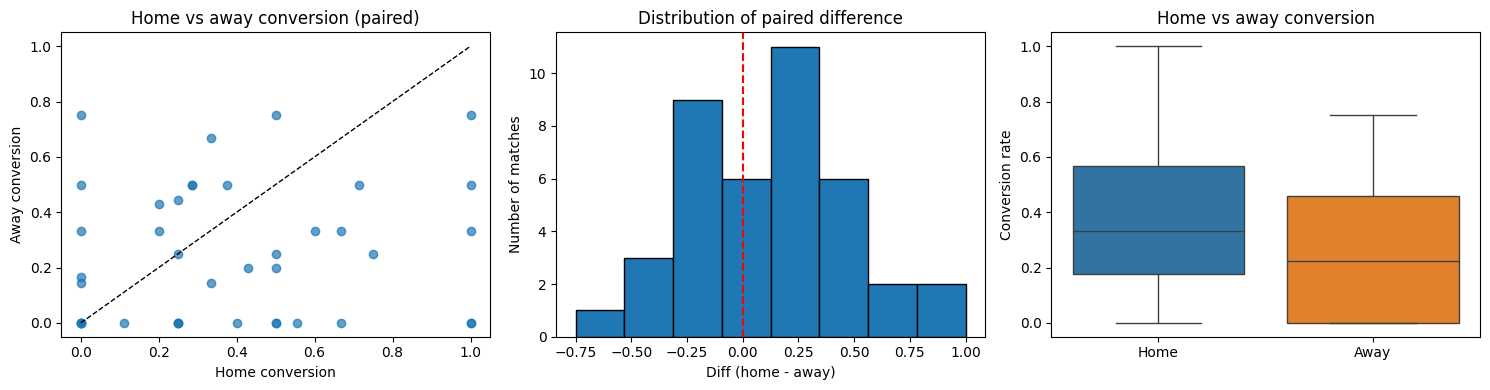

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Each dot represents one match:
#   x-axis = home team's conversion rate
#   y-axis = away team's conversion rate
axes[0].scatter(sample['home_conv'], sample['away_conv'], alpha=0.7)
# Line where home=away conversions,
# Points ABOVE the line:away conversion > home conversion
# Points BELOW the line:home conversion > away conversion
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('Home conversion')
axes[0].set_ylabel('Away conversion')
axes[0].set_title('Home vs away conversion (paired)')



# Conversion difference and number of matches. Negative means away conv is more.
axes[1].hist(sample['diff'], bins=8, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Diff (home - away)')
axes[1].set_ylabel('Number of matches')
axes[1].set_title('Distribution of paired difference')




# # BoxPlots of Home and Away conversion rates below shows:
#   - Median
#   - Middle 50% of observations (IQR)
#   - Spread/variability
#   - Potential outliers
sns.boxplot(data=[sample['home_conv'], sample['away_conv']], ax=axes[2])
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Home', 'Away'])
axes[2].set_ylabel('Conversion rate')
axes[2].set_title('Home vs away conversion')

plt.tight_layout()
plt.show()

## 8. Normality Check

**Why check for a bell curve?**

The t-test we're about to run assumes the differences are roughly bell-shaped. This
test checks that assumption. If it passes, the mean-based test is on solid ground.
If not, the median tells a more honest story than the mean would.

In [14]:
shapiro_stat, shapiro_p = stats.shapiro(sample['diff'])
print(f"Shapiro-Wilk on diff: W={shapiro_stat:.4f}, p={shapiro_p:.4f}")
print("p > 0.05 -> normality not rejected, mean-based inference is justified"
      if shapiro_p > 0.05 else
      "p <= 0.05 -> normality questionable, report median/IQR alongside the t-test")

Shapiro-Wilk on diff: W=0.9792, p=0.6614
p > 0.05 -> normality not rejected, mean-based inference is justified


## 9. 95% Confidence Interval

Uses the **t-distribution**, since the population standard deviation is unknown and estimated from the sample.

**What a confidence interval actually says?**

Instead of claiming "the difference is exactly X," a 95% confidence interval says:
"we're 95% sure the *true* difference across the whole tournament falls somewhere
between these two numbers." It's a safety margin, because we only looked at 40
matches out of 95 — not every match that happened.

In [15]:
n = len(sample)
mean_diff = sample['diff'].mean()
sd_diff = sample['diff'].std(ddof=1)
se_diff = sd_diff / np.sqrt(n)
t_crit = stats.t.ppf(0.975, df=n - 1)

ci_lower = mean_diff - t_crit * se_diff
ci_upper = mean_diff + t_crit * se_diff

print(f"Mean diff : {mean_diff:.4f}")
print(f"t* (df={n-1}) : {t_crit:.4f}")
print(f"95% CI    : ({ci_lower:.4f}, {ci_upper:.4f})")

Mean diff : 0.1399
t* (df=39) : 2.0227
95% CI    : (0.0180, 0.2618)


## 10. Hypothesis Test — Paired One-Sample t-Test

Home and away conversion come from the *same match*, sharing referee, occasion, and stakes — a matched-pairs structure. Testing the paired difference against zero is more powerful than treating the two sides as independent groups.

- H0: μ(diff) = 0 — no difference between home and away conversion
- H1: μ(diff) ≠ 0

**What the p-value is really asking?**

Is this pattern real, or could it just be luck from which 40 matches got picked?
The p-value is the probability we'd see a difference this big (or bigger) purely
by chance if home and away were *actually* identical. Below 5% (0.05), we call it
"statistically significant" — unlikely to be a random fluke.

In [16]:
t_stat, p_value = stats.ttest_1samp(sample['diff'], popmean=0)
alpha = 0.05

print(f"t({n-1}) = {t_stat:.4f}, p = {p_value:.4f}")
if p_value < alpha:
    print(f"p < {alpha} -> reject H0: home and away conversion differ significantly")
else:
    print(f"p >= {alpha} -> fail to reject H0")

t(39) = 2.3218, p = 0.0256
p < 0.05 -> reject H0: home and away conversion differ significantly


## 11. Robustness Check — Full Usable Population

Re-run the same test on all 95 usable matches (no sampling) as a sanity check. A result that flips between the sample and the full population is real sampling variability worth discussing — not an error to hide.

In [17]:
t_full, p_full = stats.ttest_1samp(usable['diff'], popmean=0)
print(f"Full population (n={len(usable)}): t={t_full:.4f}, p={p_full:.4f}, "
      f"mean diff={usable['diff'].mean():.4f}")

Full population (n=95): t=0.8887, p=0.3764, mean diff=0.0358


In our sample of 40 matches, home teams scored on about 39 out of every 100
shots on target (home goal conv = 0.39). Away teams scored on about 25 out of every 100 (away goal conv = 0.25). That is a
gap of about 14 goals per 100 shots (approx diff=0.14).

We ran the numbers and got a 95 percent confidence interval of (0.018, 0.262)
for this gap. Since this range does not touch zero, it looks like a real
difference. The t-test agreed: t(39) = 2.32, p = 0.026. Because p is under
0.05, we reject the null hypothesis. So in this sample, home teams finished
their chances better than away teams.

But then we checked something important. We ran the same test again, this
time using all 95 matches instead of just our 40. The result flipped: t = 0.89,
p = 0.376. That is way above 0.05, so at the full tournament level there is
no real difference between home and away conversion.

So the final answer to our question:
Since we have to focus on the sampled data and give verdict, it translates to **Yes, there is significant difference in home vs away goal conversion which is goals per shots on target as found from the selected random sample.**

But when looking at larger sample (n=95: not population as we excluded 9 samples to avoid divide by zero error), there seems to be no real significant difference on shot to goal conversion whether it is home or away match and this actually is more realistic if we see it in real life.